## How was data collected (text from 1st milestone):

## Data Cleaning

In [1]:
#install.packages("tidyverse")
library(tidyverse)


── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
cars_raw = read_csv("serbia_car_sales_price_2024.csv")

Rows: 8413 Columns: 18
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (11): post_info, car_name, A/C, emission_class, horsepower, color, type_...
dbl  (7): views, favorite, price, year, seats_amount, car_mileage, km, engin...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
head(cars_raw)

views,favorite,post_info,price,car_name,year,A/C,emission_class,seats_amount,horsepower,color,"car_mileage, km","engine_capacity, cc",type_of_drive,doors,fuel,car_type,gearbox
<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
58,0,posted a week ago,1100,Alfa Romeo 11.9,2002,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
55,0,posted 2 days ago,1100,Alfa Romeo 145,2000,manual A/C,Euro 3,5,106 HP (78 kW),gray,158546,1400,front,2/3 doors,petrol + gas,hatchback,"manual, 5 speeds"
136,4,posted 2 weeks ago,950,Alfa Romeo 145,1999,manual A/C,Euro 3,5,105 HP (77 kW),green,337000,1910,front,2/3 doors,diesel,hatchback,"manual, 5 speeds"
209,1,posted 4 weeks ago,500,Alfa Romeo 146,2000,manual A/C,Euro 3,5,120 HP (88 kW),gray,200000,1600,front,4/5 doors,petrol + gas,limousine,"manual, 5 speeds"
61,0,posted 2 days ago,111,Alfa Romeo 147,2024,automatic A/C,NA,5,116 HP (85 kW),gray,280000,1900,front,2/3 doors,diesel,hatchback,"manual, 5 speeds"
196,2,posted 4 weeks ago,2300,Alfa Romeo 147,2008,no A/C,NA,5,105 HP (77 kW),black,188000,1600,front,4/5 doors,petrol + gas,hatchback,"manual, 5 speeds"


In [4]:
str(cars_raw)

spc_tbl_ [8,413 × 18] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ views              : num [1:8413] 58 55 136 209 61 ...
 $ favorite           : num [1:8413] 0 0 4 1 0 2 1 6 16 0 ...
 $ post_info          : chr [1:8413] "posted a week ago" "posted 2 days ago" "posted 2 weeks ago" "posted 4 weeks ago" ...
 $ price              : num [1:8413] 1100 1100 950 500 111 2300 3500 2150 1350 2000 ...
 $ car_name           : chr [1:8413] "Alfa Romeo 11.9" "Alfa Romeo 145" "Alfa Romeo 145" "Alfa Romeo 146" ...
 $ year               : num [1:8413] 2002 2000 1999 2000 2024 ...
 $ A/C                : chr [1:8413] NA "manual A/C" "manual A/C" "manual A/C" ...
 $ emission_class     : chr [1:8413] NA "Euro 3" "Euro 3" "Euro 3" ...
 $ seats_amount       : num [1:8413] NA 5 5 5 5 5 5 5 5 5 ...
 $ horsepower         : chr [1:8413] NA "106 HP (78 kW)" "105 HP (77 kW)" "120 HP (88 kW)" ...
 $ color              : chr [1:8413] NA "gray" "green" "gray" ...
 $ car_mileage, km    : num [1:8413] NA 158546 337000 

In [5]:
summary(cars_raw)

     views            favorite        post_info             price      
 Min.   :    0.0   Min.   :  0.000   Length:8413        Min.   :  100  
 1st Qu.:   61.0   1st Qu.:  0.000   Class :character   1st Qu.: 1600  
 Median :  114.0   Median :  1.000   Mode  :character   Median : 3300  
 Mean   :  308.7   Mean   :  2.672                      Mean   : 4848  
 3rd Qu.:  245.0   3rd Qu.:  3.000                      3rd Qu.: 5950  
 Max.   :27770.0   Max.   :151.000                      Max.   :82000  
                                                                       
   car_name              year          A/C            emission_class    
 Length:8413        Min.   :1960   Length:8413        Length:8413       
 Class :character   1st Qu.:2003   Class :character   Class :character  
 Mode  :character   Median :2006   Mode  :character   Mode  :character  
                    Mean   :2006                                        
                    3rd Qu.:2010                           

In [6]:
problems(cars_raw)

row,col,expected,actual,file
<int>,<int>,<chr>,<chr>,<chr>


#### Renaming columns for better readability

In [7]:
cars_raw <- cars_raw %>%
rename(post_date=post_info, price_eur=price, ac=`A/C`, seats=seats_amount, mileage_km=`car_mileage, km`, engine_capacity_cc=`engine_capacity, cc`)

#### Casting columns to integer and adding an ID column

In [8]:
cars_raw <- cars_raw %>%
mutate(across(c(views, favorite, price_eur, year, seats, mileage_km, engine_capacity_cc), as.integer)) %>%
mutate(id = row_number()) %>%
relocate(id, .before = 1)

Warning message:
"There was 1 warning in `mutate()`.
ℹ In argument: `across(...)`.
Caused by warning:
! NAs introduced by coercion to integer range"


#### Cleaning and formatting post_date column

In [9]:
cars_raw <- cars_raw %>%
mutate(post_date = str_remove(post_date, "^(posted|updated)\\s?"))

In [10]:
sum(is.na(cars_raw$post_date))

cars_raw %>%
distinct(post_date)

[1] 0

post_date
<chr>
a week ago
2 days ago
2 weeks ago
4 weeks ago
5 days ago
6 days ago
3 weeks ago
yesterday
3 days ago


#### Cleaning ac, emission, horsepower and doors column

In [11]:
sum(is.na(cars_raw$ac))

cars_raw %>%
distinct(ac)

[1] 10

ac
<chr>
NA
manual A/C
automatic A/C
no A/C


In [12]:
cars_raw <- cars_raw %>%
mutate(ac = str_trim(str_remove(ac, "A/C$"))) %>%
mutate(emission_class = str_remove(emission_class, "^Euro\\s?")) %>%
mutate(emission_class = as.integer(emission_class)) %>%
mutate(horsepower = str_extract(horsepower, "^[0-9]+") %>% as.numeric()) %>%
mutate(horsepower = as.integer(horsepower)) %>%
mutate(doors = str_trim(str_remove(doors, "doors$")))

In [13]:
cars_raw %>%
count(color, sort = TRUE)

# Color names are OK

color,n
<chr>,<int>
gray,2628
black,1699
white,1068
blue,889
red,582
teget,364
silver,312
green,275
brown,113


#### Splitting gearbox column into type and speeds

In [14]:
cars_raw %>%
count(gearbox, sort = TRUE)

gearbox,n
<chr>,<int>
"manual, 5 speeds",4645
"manual, 6 speeds",2323
automatic,1164
"manual, 4 speeds",168
semi-automatic,85
"manual, multiple speeds",18
NA,10


In [15]:
cars_raw <- cars_raw %>%
  mutate(
    # Splitting on comma (if there's none, the 'speeds_raw' will be NA)
    speeds_raw = str_split_i(gearbox, ", ", 2),
    gearbox = str_split_i(gearbox, ", ", 1),
    
    
    # Extracting number from speeds_raw, if there's none it will be 0
    speeds = str_extract(speeds_raw, "[0-9]+") %>% as.numeric(),
    speeds = ifelse(is.na(speeds), 0, speeds)
  ) %>%
  select(-speeds_raw) %>%
  mutate(speeds = as.integer(speeds))

#### Transforming car_name into brand and model columns

In [16]:
brands <- c("Alfa Romeo", "Audi", "BMW", "Chevrolet", "Chrysler", "Citroen", 
           "Dacia", "Daewoo", "Daihatsu", "Dodge", "Fiat", "Ford", "Honda", 
           "Hyundai", "Isuzu", "Iveco", "Jaguar", "Jeep", "Kia", "Lada", 
           "Lancia", "Land Rover", "Lexus", "Maserati", "Mazda", "Mercedes", 
           "MG", "Mini", "Mitsubishi", "Moskwitch", "Nissan", "Opel", 
           "Peugeot", "Pontiac", "Porsche", "Renault", "Rover", "Saab", 
           "Seat", "Skoda", "Smart", "SsangYong", "Subaru", "Suzuki", 
           "Tesla", "Toyota", "Trabant", "UAZ", "Volkswagen", "Volvo", 
           "VW", "Wartburg", "Zastava")

# Creating regex
brand_regex <- paste0("^(", paste(sort(brands, decreasing = TRUE), collapse = "|"), ")")

cars_raw <- cars_raw %>%
  mutate(
    brand = str_extract(car_name, brand_regex),
    model = str_remove(car_name, brand_regex) %>% str_trim()
  ) %>%
  select(-car_name) %>% 
  relocate(brand, model, .after = 3)

In [17]:
cars_raw %>%
count(brand, sort = TRUE)

brand,n
<chr>,<int>
Volkswagen,1229
Opel,822
Audi,664
Renault,643
Fiat,619
Peugeot,578
BMW,515
Mercedes,443
Ford,441


In [18]:
cars_raw <- cars_raw %>%
mutate(brand = str_replace(brand, "^VW$", "Volkswagen"))

#### Transforming post_date into days_passed column

In [19]:
cars_raw <- cars_raw %>%
  mutate(post_date = case_when(
    str_detect(post_date, "today")      ~ 0L,
    str_detect(post_date, "yesterday")  ~ 1L,
    str_detect(post_date, "2 days")     ~ 2L,
    str_detect(post_date, "3 days")     ~ 3L,
    str_detect(post_date, "4 days")     ~ 4L,
    str_detect(post_date, "5 days")     ~ 5L,
    str_detect(post_date, "6 days")     ~ 6L,
    str_detect(post_date, "a week ago") ~ 7L,
    str_detect(post_date, "2 weeks")    ~ 14L,
    str_detect(post_date, "3 weeks")    ~ 21L,
    str_detect(post_date, "4 weeks")    ~ 28L,
    str_detect(post_date, "month")      ~ 30L,
    TRUE ~ NA_integer_
  )) %>%
rename(days_passed=post_date)

In [20]:
str(cars_raw)

tibble [8,413 × 21] (S3: tbl_df/tbl/data.frame)
 $ id                : int [1:8413] 1 2 3 4 5 6 7 8 9 10 ...
 $ views             : int [1:8413] 58 55 136 209 61 196 133 290 2629 89 ...
 $ favorite          : int [1:8413] 0 0 4 1 0 2 1 6 16 0 ...
 $ brand             : chr [1:8413] "Alfa Romeo" "Alfa Romeo" "Alfa Romeo" "Alfa Romeo" ...
 $ model             : chr [1:8413] "11.9" "145" "145" "146" ...
 $ days_passed       : int [1:8413] 7 2 14 28 2 28 5 6 7 7 ...
 $ price_eur         : int [1:8413] 1100 1100 950 500 111 2300 3500 2150 1350 2000 ...
 $ year              : int [1:8413] 2002 2000 1999 2000 2024 2008 2008 2008 2008 2007 ...
 $ ac                : chr [1:8413] NA "manual" "manual" "manual" ...
 $ emission_class    : int [1:8413] NA 3 3 3 NA NA 4 4 4 4 ...
 $ seats             : int [1:8413] NA 5 5 5 5 5 5 5 5 5 ...
 $ horsepower        : int [1:8413] NA 106 105 120 116 105 170 90 120 105 ...
 $ color             : chr [1:8413] NA "gray" "green" "gray" ...
 $ mileage_km      

In [21]:
summary(cars_raw)

       id           views            favorite          brand          
 Min.   :   1   Min.   :    0.0   Min.   :  0.000   Length:8413       
 1st Qu.:2104   1st Qu.:   61.0   1st Qu.:  0.000   Class :character  
 Median :4207   Median :  114.0   Median :  1.000   Mode  :character  
 Mean   :4207   Mean   :  308.7   Mean   :  2.672                     
 3rd Qu.:6310   3rd Qu.:  245.0   3rd Qu.:  3.000                     
 Max.   :8413   Max.   :27770.0   Max.   :151.000                     
                                                                      
    model            days_passed      price_eur          year     
 Length:8413        Min.   : 0.00   Min.   :  100   Min.   :1960  
 Class :character   1st Qu.: 4.00   1st Qu.: 1600   1st Qu.:2003  
 Mode  :character   Median : 7.00   Median : 3300   Median :2006  
                    Mean   : 9.64   Mean   : 4848   Mean   :2006  
                    3rd Qu.:14.00   3rd Qu.: 5950   3rd Qu.:2010  
                    Max.   :30

#### Checking the values of every column (missing values, outliers etc.)

In [22]:
cars_raw %>%
filter(views < favorite)

id,views,favorite,brand,model,days_passed,price_eur,year,ac,emission_class,⋯,horsepower,color,mileage_km,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds
<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<int>,⋯,<int>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
680,0,1,Audi,A6,0,3000,2004,automatic,3,⋯,150,red,222000,1790,front,4/5,petrol + gas,caravan,manual,5
727,0,1,Audi,A8,0,4450,2005,automatic,3,⋯,237,black,340000,3000,4x4,4/5,diesel,limousine,automatic,0
4952,0,1,Opel,Zafira,0,650,2004,manual,3,⋯,101,bordeaux,290884,1995,front,4/5,diesel,minivan (MPV),manual,5
5256,0,2,Peugeot,306,0,350,2001,no,3,⋯,75,gray,280000,1899,front,4/5,diesel,caravan,manual,5
6685,0,1,Smart,Fortwo,0,120,2001,no,3,⋯,61,black,12100,599,back,2/3,petrol,coupe,manual,6


In [23]:
cars_raw <- cars_raw %>%
filter(views >= favorite)

In [24]:
cars_raw %>%
select(model, brand) %>%
arrange(model, brand) %>%
count(model, brand) %>%
print(n = 5) #Inf

# A tibble: 714 × 3
  model brand        n
  <chr> <chr>    <int>
1 1.3   Wartburg     1
2 10    Zastava      5
3 100   Audi         6
4 1000  Mini         1
5 1007  Peugeot      6
# ℹ 709 more rows


In [25]:
# Filtering cars that have unrealistic prices

cars_raw <- cars_raw %>%
filter(!(price_eur < 200 & brand %in% c('Audi', 'Mercedes'))) %>%
filter(!(price_eur < 800 & year > 2010))

In [26]:
cars_raw %>%
count(emission_class)

emission_class,n
<int>,<int>
1,218
2,342
3,1817
4,2505
5,1457
6,720
NA,1333


In [27]:
cars_raw %>%
count(seats)

cars_raw %>%
filter(is.na(seats))

seats,n
<int>,<int>
2,225
3,38
4,558
5,7163
6,38
7,334
8,5
9,21
NA,10


id,views,favorite,brand,model,days_passed,price_eur,year,ac,emission_class,⋯,horsepower,color,mileage_km,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds
<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<int>,⋯,<int>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
1,58,0,Alfa Romeo,11.9,7,1100,2002,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,0
232,36,1,Audi,A3,7,4300,2007,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,0
1359,152,2,Chevrolet,Tacuma,14,400,2006,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,0
1704,18,0,Citroen,DS3,14,6000,2012,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,0
6645,664,5,Skoda,Yeti,14,6600,2010,NA,NA,⋯,NA,NA,181000,NA,4x4,NA,diesel,suv,NA,0
8188,160,0,Volvo,S90,7,27200,2017,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,0
8247,457,2,Volkswagen,Buba,7,26000,1960,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,0
8248,8124,68,Volkswagen,Buba,14,6500,1967,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,0
8249,86,1,Volkswagen,Buba,4,3199,1971,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,0


In [28]:
# median: 5.00
# mean  : 4.94
# NA can be filled with 5.

cars_raw <- cars_raw %>%
replace_na(list(seats = 5L))

In [29]:
# dropping rows with unrealistic HP values (over 500 HP for cars that have way less in normal case)
cars_raw <- cars_raw %>%
filter(!id %in% c(36, 1878, 2431, 3271, 4635, 6714))


In [30]:
colSums(is.na(cars_raw))

id              views           favorite              brand 
                 0                  0                  0                  0 
             model        days_passed          price_eur               year 
                 0                  0                  0                  0 
                ac     emission_class              seats         horsepower 
                10               1329                  0                 10 
             color         mileage_km engine_capacity_cc      type_of_drive 
                10                 14                 10                  9 
             doors               fuel           car_type            gearbox 
                10                  9                  8                 10 
            speeds 
                 0

In [31]:
cars_raw <- cars_raw %>%
filter(horsepower > 20)

# Also filtered rows with NA's at horsepower (and this way engine_capacity_cc)

In [32]:
colSums(is.na(cars_raw))

id              views           favorite              brand 
                 0                  0                  0                  0 
             model        days_passed          price_eur               year 
                 0                  0                  0                  0 
                ac     emission_class              seats         horsepower 
                 0               1311                  0                  0 
             color         mileage_km engine_capacity_cc      type_of_drive 
                 0                  5                  0                  0 
             doors               fuel           car_type            gearbox 
                 0                  0                  0                  0 
            speeds 
                 0

In [33]:
# Assumption: if it's over 1.000.000 maybe the decimal part was also written there so I divide with 10.
# If it's still over 1.000.000 after the division the row gets dropped.
cars_raw <- cars_raw %>%
mutate(mileage_km = if_else(mileage_km > 1000000, 
                            mileage_km / 10, 
                            mileage_km)) %>%
mutate(mileage_km = round(mileage_km)) %>%
filter(mileage_km < 999999) %>%

# Assumption: the low mileages can be a mistake by the owner e.g. 265 instead of 265.000
# These rows all looked like they fit this assumption based on the other attributes
mutate(mileage_km = if_else(mileage_km > 80 & mileage_km < 400, 
                            mileage_km * 1000, 
                            mileage_km))

In [34]:
cars_raw <- cars_raw %>%
filter(mileage_km > 1000)

In [35]:
# A 0 was likely missed at the end for these rows, it makes sense based on the other attributes 
cars_raw <- cars_raw %>%
mutate(engine_capacity_cc = if_else(engine_capacity_cc < 300,
                                    engine_capacity_cc * 10,
                                    engine_capacity_cc)) %>%
filter(!id %in% c(792, 1056, 1057, 4950, 6860))
# dropping unrealistic values (over 5000 CC for not fitting cars, e.g. ~10000 CC for an Opel Zafira)

In [36]:
cars_raw <- cars_raw %>%
mutate(car_type = str_replace(car_type, "minivan \\(MPV\\)", "minivan"))

In [37]:
cars_raw <- cars_raw %>%
mutate(across(c(mileage_km, engine_capacity_cc), as.integer))

In [38]:
problems(cars_raw)

In [39]:
colSums(is.na(cars_raw))

id              views           favorite              brand 
                 0                  0                  0                  0 
             model        days_passed          price_eur               year 
                 0                  0                  0                  0 
                ac     emission_class              seats         horsepower 
                 0               1294                  0                  0 
             color         mileage_km engine_capacity_cc      type_of_drive 
                 0                  0                  0                  0 
             doors               fuel           car_type            gearbox 
                 0                  0                  0                  0 
            speeds 
                 0

In [40]:
summary(cars_raw)

       id           views            favorite        brand          
 Min.   :   2   Min.   :    0.0   Min.   : 0.00   Length:8289       
 1st Qu.:2107   1st Qu.:   61.0   1st Qu.: 0.00   Class :character  
 Median :4210   Median :  113.0   Median : 1.00   Mode  :character  
 Mean   :4206   Mean   :  303.1   Mean   : 2.63                     
 3rd Qu.:6306   3rd Qu.:  242.0   3rd Qu.: 3.00                     
 Max.   :8413   Max.   :17011.0   Max.   :73.00                     
                                                                    
    model            days_passed       price_eur          year     
 Length:8289        Min.   : 0.000   Min.   :  100   Min.   :1970  
 Class :character   1st Qu.: 4.000   1st Qu.: 1650   1st Qu.:2003  
 Mode  :character   Median : 7.000   Median : 3300   Median :2006  
                    Mean   : 9.628   Mean   : 4857   Mean   :2006  
                    3rd Qu.:14.000   3rd Qu.: 5990   3rd Qu.:2010  
                    Max.   :30.000   Max

In [41]:
glimpse(cars_raw)

Rows: 8,289
Columns: 21
$ id                 <int> 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17…
$ views              <int> 55, 136, 209, 196, 133, 290, 2629, 89, 64, 1265, 11…
$ favorite           <int> 0, 4, 1, 2, 1, 6, 16, 0, 0, 17, 2, 4, 16, 0, 4, 4, …
$ brand              <chr> "Alfa Romeo", "Alfa Romeo", "Alfa Romeo", "Alfa Rom…
$ model              <chr> "145", "145", "146", "147", "147", "147", "147", "1…
$ days_passed        <int> 2, 14, 28, 28, 5, 6, 7, 7, 7, 7, 21, 7, 14, 2, 7, 2…
$ price_eur          <int> 1100, 950, 500, 2300, 3500, 2150, 1350, 2000, 2500,…
$ year               <int> 2000, 1999, 2000, 2008, 2008, 2008, 2008, 2007, 200…
$ ac                 <chr> "manual", "manual", "manual", "no", "automatic", "m…
$ emission_class     <int> 3, 3, 3, NA, 4, 4, 4, 4, NA, 5, 4, 3, 3, NA, 3, NA,…
$ seats              <int> 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 5, 5, …
$ horsepower         <int> 106, 105, 120, 105, 170, 90, 120, 105, 105, 120, 12…
$ color         

In [42]:
#install.packages("skimr")
library(skimr)
skim(cars_raw)

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,brand,0,1.0000000,2,10,0,52,0,NA,NA,NA,NA,NA,NA,NA,NA
2,character,model,0,1.0000000,1,25,0,691,0,NA,NA,NA,NA,NA,NA,NA,NA
3,character,ac,0,1.0000000,2,9,0,3,0,NA,NA,NA,NA,NA,NA,NA,NA
4,character,color,0,1.0000000,3,12,0,19,0,NA,NA,NA,NA,NA,NA,NA,NA
5,character,type_of_drive,0,1.0000000,3,5,0,3,0,NA,NA,NA,NA,NA,NA,NA,NA
6,character,doors,0,1.0000000,3,3,0,2,0,NA,NA,NA,NA,NA,NA,NA,NA
7,character,fuel,0,1.0000000,3,12,0,8,0,NA,NA,NA,NA,NA,NA,NA,NA
8,character,car_type,0,1.0000000,3,9,0,8,0,NA,NA,NA,NA,NA,NA,NA,NA
9,character,gearbox,0,1.0000000,6,14,0,3,0,NA,NA,NA,NA,NA,NA,NA,NA


In [43]:
#install.packages("dlookr")
library(dlookr)
diagnose(cars_raw)

Registered S3 methods overwritten by 'dlookr':
  method          from  
  plot.transform  scales
  print.transform scales


Kapcsolódás csomaghoz: 'dlookr'


The following object is masked from 'package:tidyr':

    extract


The following object is masked from 'package:base':

    transform




variables,types,missing_count,missing_percent,unique_count,unique_rate
<chr>,<chr>,<int>,<dbl>,<int>,<dbl>
id,integer,0,0.00000,8289,1.0000000000
views,integer,0,0.00000,1200,0.1447701773
favorite,integer,0,0.00000,53,0.0063940162
brand,character,0,0.00000,52,0.0062733744
model,character,0,0.00000,691,0.0833634938
days_passed,integer,0,0.00000,12,0.0014477018
price_eur,integer,0,0.00000,756,0.0912052117
year,integer,0,0.00000,55,0.0066352998
ac,character,0,0.00000,3,0.0003619254


In [44]:
cars <- cars_raw
head(cars, 8)

id,views,favorite,brand,model,days_passed,price_eur,year,ac,emission_class,⋯,horsepower,color,mileage_km,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds
<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<int>,⋯,<int>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
2,55,0,Alfa Romeo,145,2,1100,2000,manual,3,⋯,106,gray,158546,1400,front,2/3,petrol + gas,hatchback,manual,5
3,136,4,Alfa Romeo,145,14,950,1999,manual,3,⋯,105,green,337000,1910,front,2/3,diesel,hatchback,manual,5
4,209,1,Alfa Romeo,146,28,500,2000,manual,3,⋯,120,gray,200000,1600,front,4/5,petrol + gas,limousine,manual,5
6,196,2,Alfa Romeo,147,28,2300,2008,no,NA,⋯,105,black,188000,1600,front,4/5,petrol + gas,hatchback,manual,5
7,133,1,Alfa Romeo,147,5,3500,2008,automatic,4,⋯,170,black,255000,1929,front,4/5,diesel,hatchback,manual,6
8,290,6,Alfa Romeo,147,6,2150,2008,manual,4,⋯,90,black,214000,1600,front,4/5,petrol + gas,hatchback,manual,5
9,2629,16,Alfa Romeo,147,7,1350,2008,automatic,4,⋯,120,white,315000,1910,front,4/5,diesel,hatchback,manual,6
10,89,0,Alfa Romeo,147,7,2000,2007,no,4,⋯,105,black,176853,1597,front,4/5,petrol,hatchback,manual,5


In [45]:
#saveRDS(cars, "cars.rds")

## Data is cleaned, continue with data engineering

In [46]:
cars <- cars %>%
add_column(views_per_day = round(cars$views / (cars$days_passed + 1), 2), .after = "days_passed") %>%
mutate(
    favs_per_10_views = if_else(
      views == 0, 
      0,
      round(favorite / (views / 10), 2)
    ),
    .after = views_per_day
  ) %>%
# Data was scraped in October 2024
add_column(kms_per_year = as.integer(round(cars$mileage_km / (2024 - cars$year + 1))), .after = "mileage_km")

In [47]:
cars %>%
count(ac)

cars %>%
count(gearbox)

cars %>%
count(type_of_drive)

ac,n
<chr>,<int>
automatic,3744
manual,3147
no,1398


gearbox,n
<chr>,<int>
automatic,1152
manual,7053
semi-automatic,84


type_of_drive,n
<chr>,<int>
4x4,897
back,767
front,6625


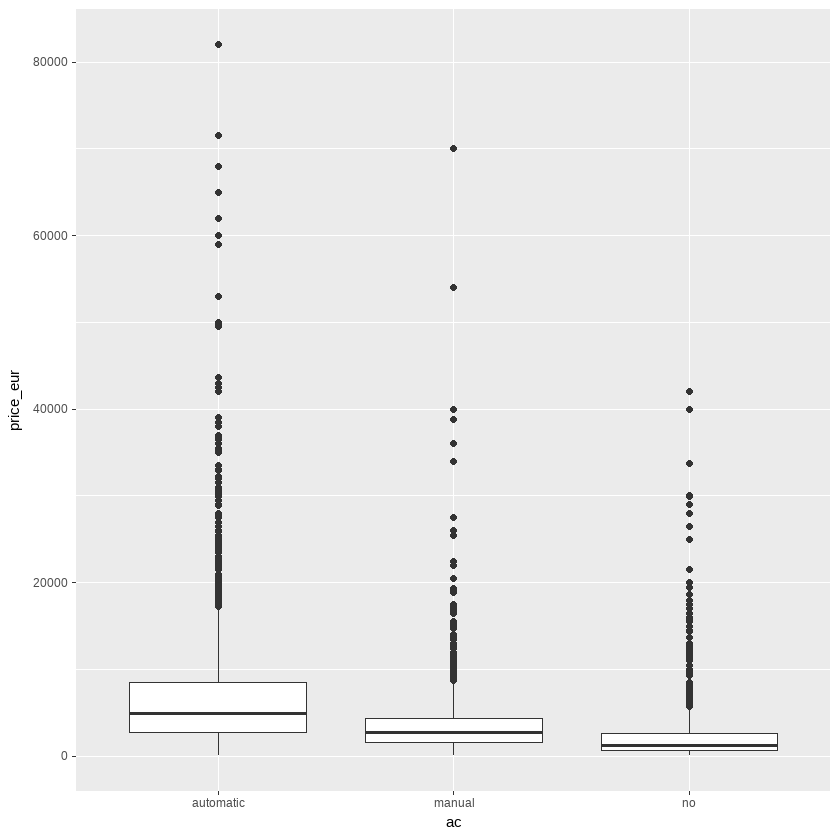

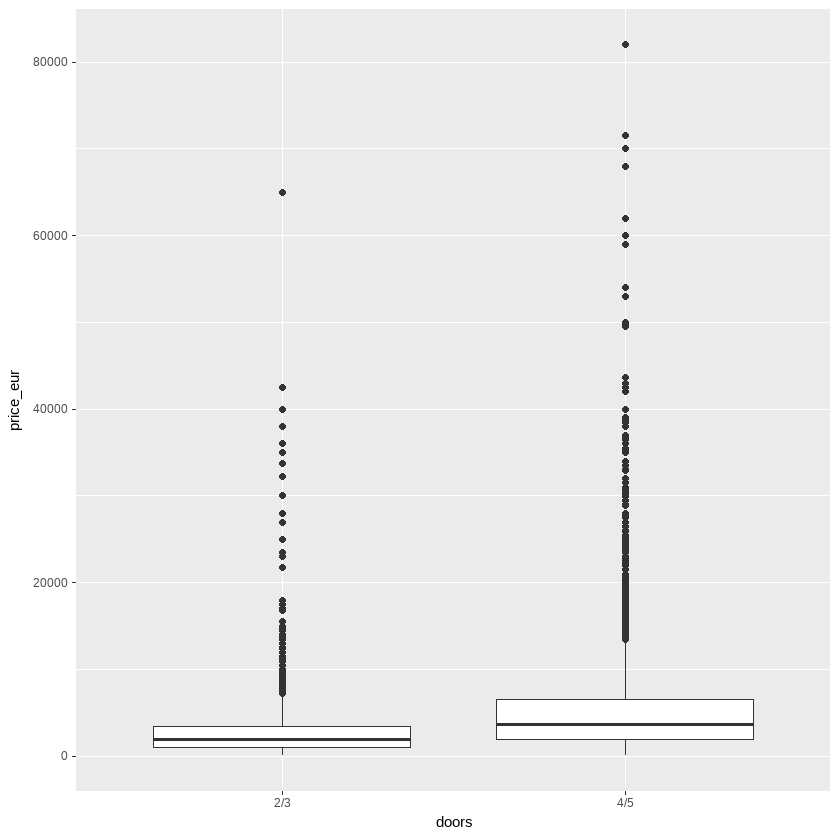

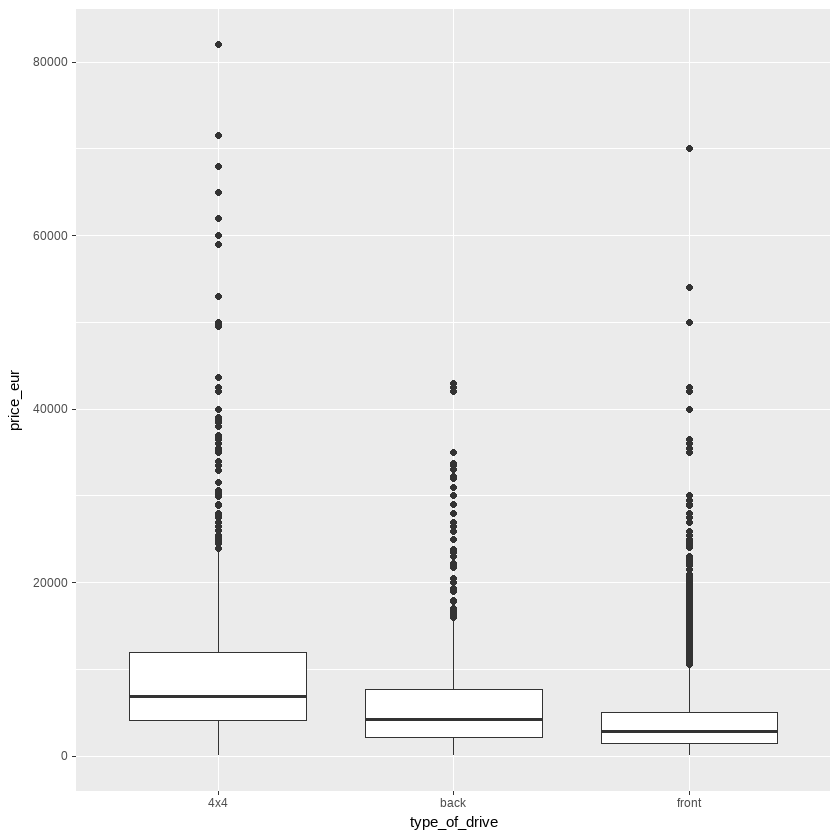

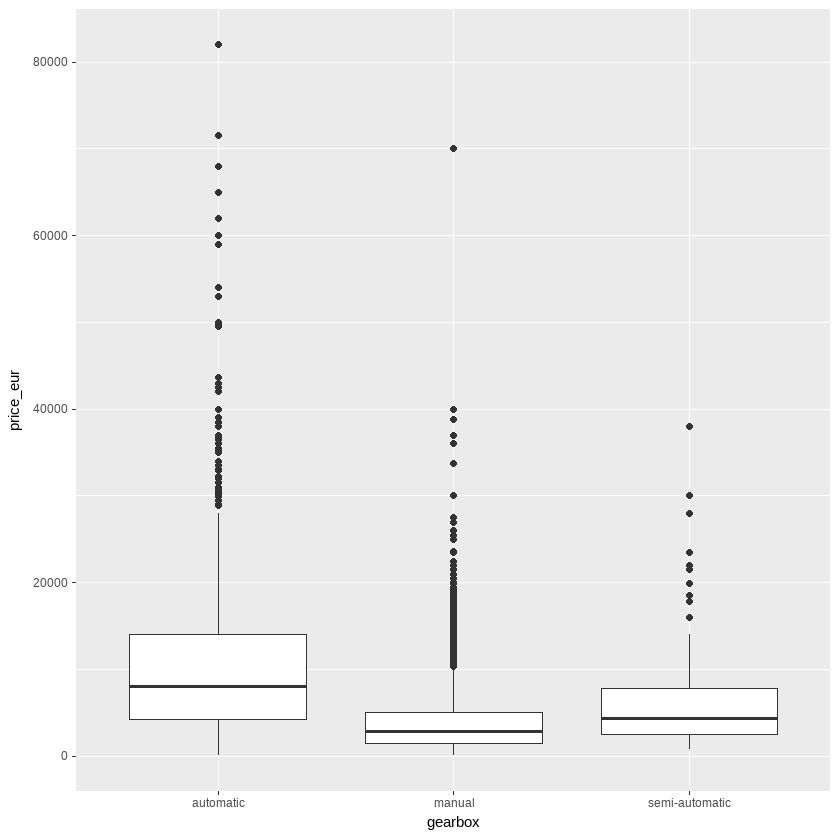

In [48]:
ggplot(cars, aes(x=ac, y=price_eur)) + geom_boxplot()

ggplot(cars, aes(x=doors, y=price_eur)) + geom_boxplot()

ggplot(cars, aes(x=type_of_drive, y=price_eur)) + geom_boxplot()

ggplot(cars, aes(x=gearbox, y=price_eur)) + geom_boxplot()

In [49]:
library(recipes)


Kapcsolódás csomaghoz: 'recipes'


The following object is masked from 'package:stringr':

    fixed


The following object is masked from 'package:stats':

    step




In [50]:
car_recipe_data_eng <- recipe(price_eur ~ ., data = cars) %>%
  # Ordinal Encoding (higher number usually means higher price, e.g. automatic is usually the most expensive)
  step_mutate(
    ac = case_when(
      ac == "no"        ~ 0L,
      ac == "manual"    ~ 1L,
      ac == "automatic" ~ 2L,
    ),
    doors = case_when(
      doors == "2/3"    ~ 3L,
      doors == "4/5"    ~ 5L,
    ),
    type_of_drive = case_when(
      type_of_drive == "front"  ~ 0L,
      type_of_drive == "back"   ~ 1L,
      type_of_drive == "4x4"    ~ 2L,
    ),
    gearbox = case_when(
      gearbox == "manual"         ~ 0L,
      gearbox == "semi-automatic" ~ 1L,
      gearbox == "automatic"      ~ 2L,
    )
  ) %>%
  # Handling missing values (emission_class)
  step_impute_median(all_numeric_predictors()) %>%
  prep()

cars <- bake(car_recipe_data_eng, new_data = NULL)

head(cars)

id,views,favorite,brand,model,days_passed,views_per_day,favs_per_10_views,year,ac,⋯,mileage_km,kms_per_year,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds,price_eur
<int>,<int>,<int>,<fct>,<fct>,<int>,<dbl>,<dbl>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,<int>,<int>,<int>
2,55,0,Alfa Romeo,145,2,18.33,0.00,2000,1,⋯,158546,6342,1400,0,3,petrol + gas,hatchback,0,5,1100
3,136,4,Alfa Romeo,145,14,9.07,0.29,1999,1,⋯,337000,12962,1910,0,3,diesel,hatchback,0,5,950
4,209,1,Alfa Romeo,146,28,7.21,0.05,2000,1,⋯,200000,8000,1600,0,5,petrol + gas,limousine,0,5,500
6,196,2,Alfa Romeo,147,28,6.76,0.10,2008,0,⋯,188000,11059,1600,0,5,petrol + gas,hatchback,0,5,2300
7,133,1,Alfa Romeo,147,5,22.17,0.08,2008,2,⋯,255000,15000,1929,0,5,diesel,hatchback,0,6,3500
8,290,6,Alfa Romeo,147,6,41.43,0.21,2008,1,⋯,214000,12588,1600,0,5,petrol + gas,hatchback,0,5,2150


## Statistics and diagrams

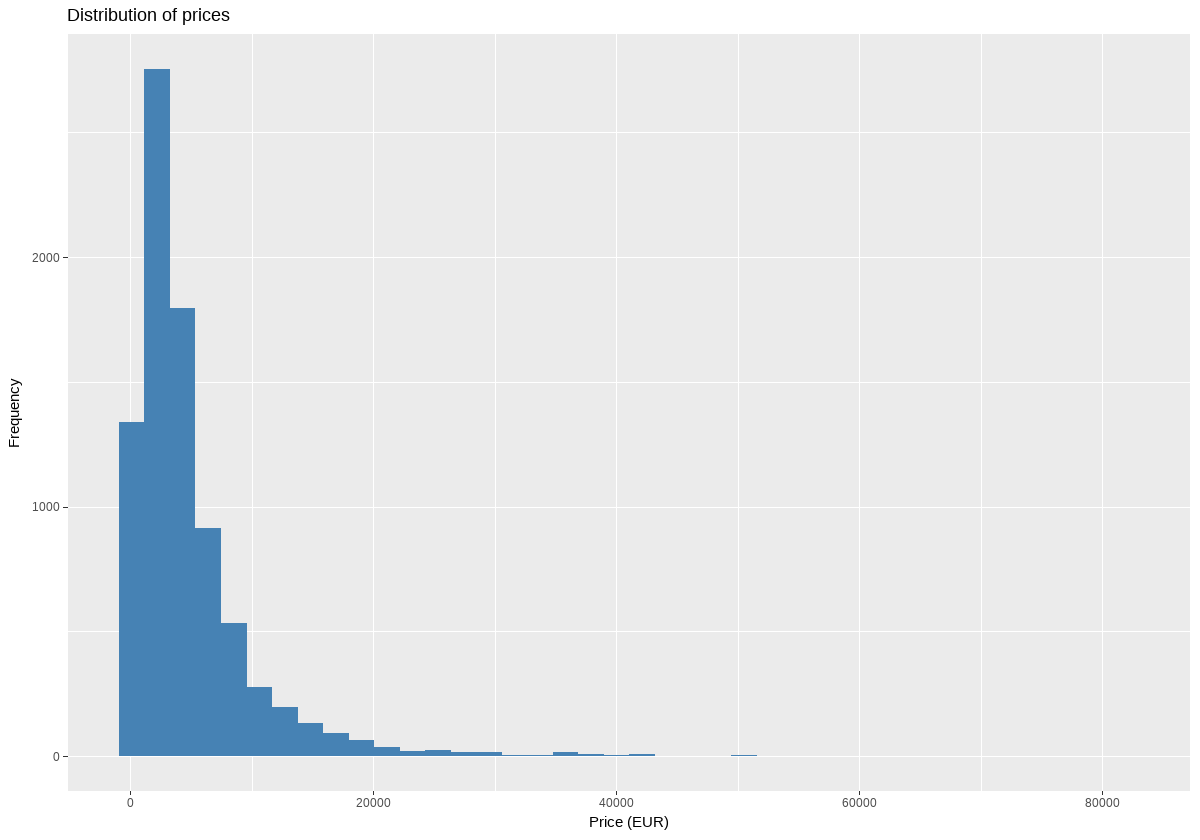

In [70]:
options(repr.plot.width = 10, repr.plot.height = 7)

ggplot(cars, aes(x = price_eur)) +
  geom_histogram(fill = "steelblue", bins = 40) +
  labs(title = "Distribution of prices", x = "Price (EUR)", y = "Frequency")

`geom_smooth()` using formula = 'y ~ s(x, bs = "cs")'


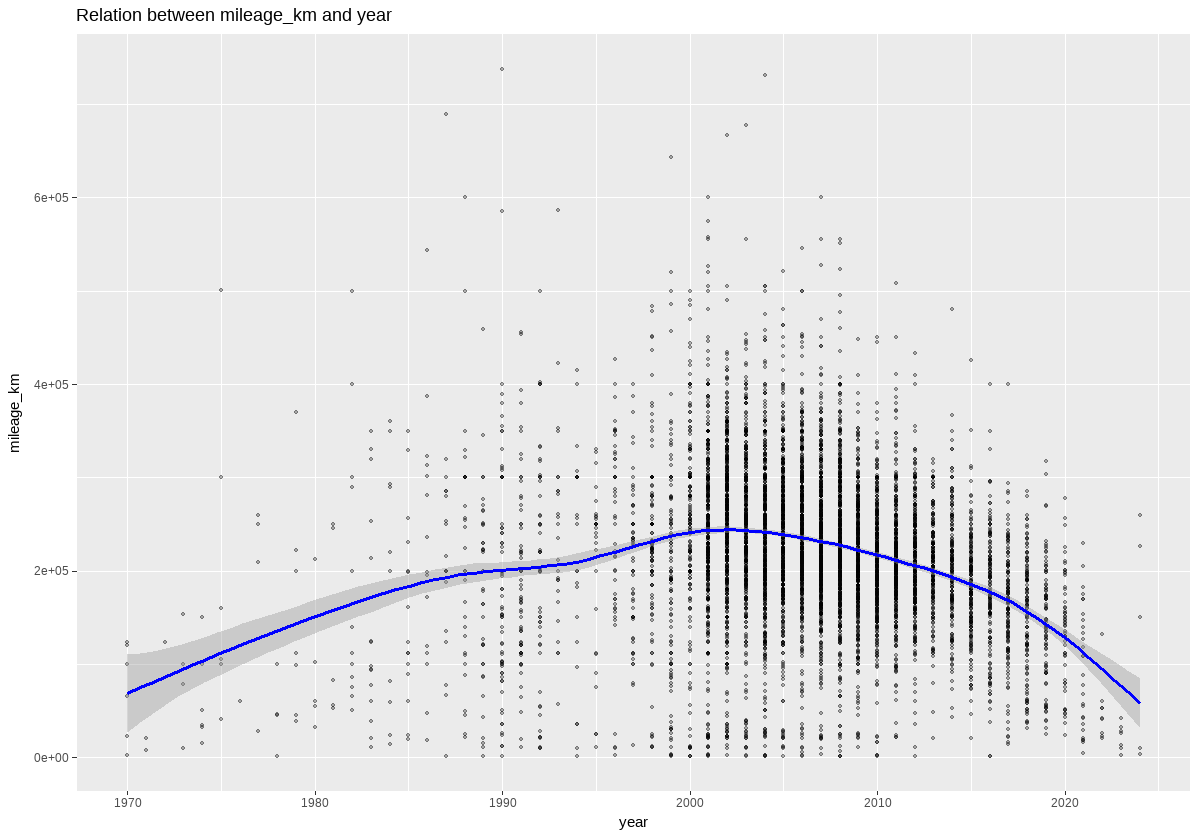

In [52]:
ggplot(cars, aes(x=year, y=mileage_km)) +
  geom_point(color="black", size=0.9, alpha=0.3) +
  geom_smooth(method = "gam", color = "blue", se = TRUE) + 
  labs(title="Relation between mileage_km and year", x="year", y="mileage_km")

`geom_smooth()` using formula = 'y ~ s(x, bs = "cs")'


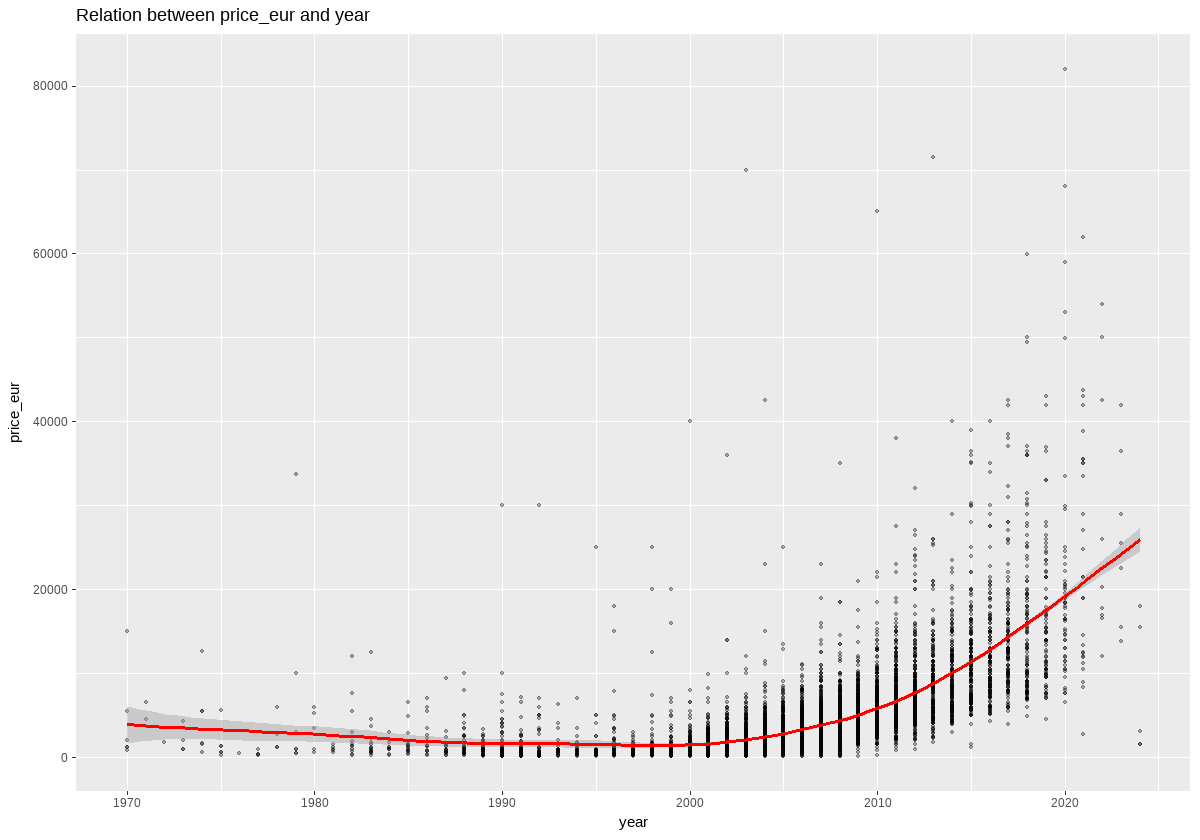

In [53]:
ggplot(cars, aes(x = year, y = price_eur)) +
  geom_point(size = 0.9, alpha = 0.3, color = "black") +
  geom_smooth(method = "gam", color = "red", se = TRUE) +
  labs(title = "Relation between price_eur and year")

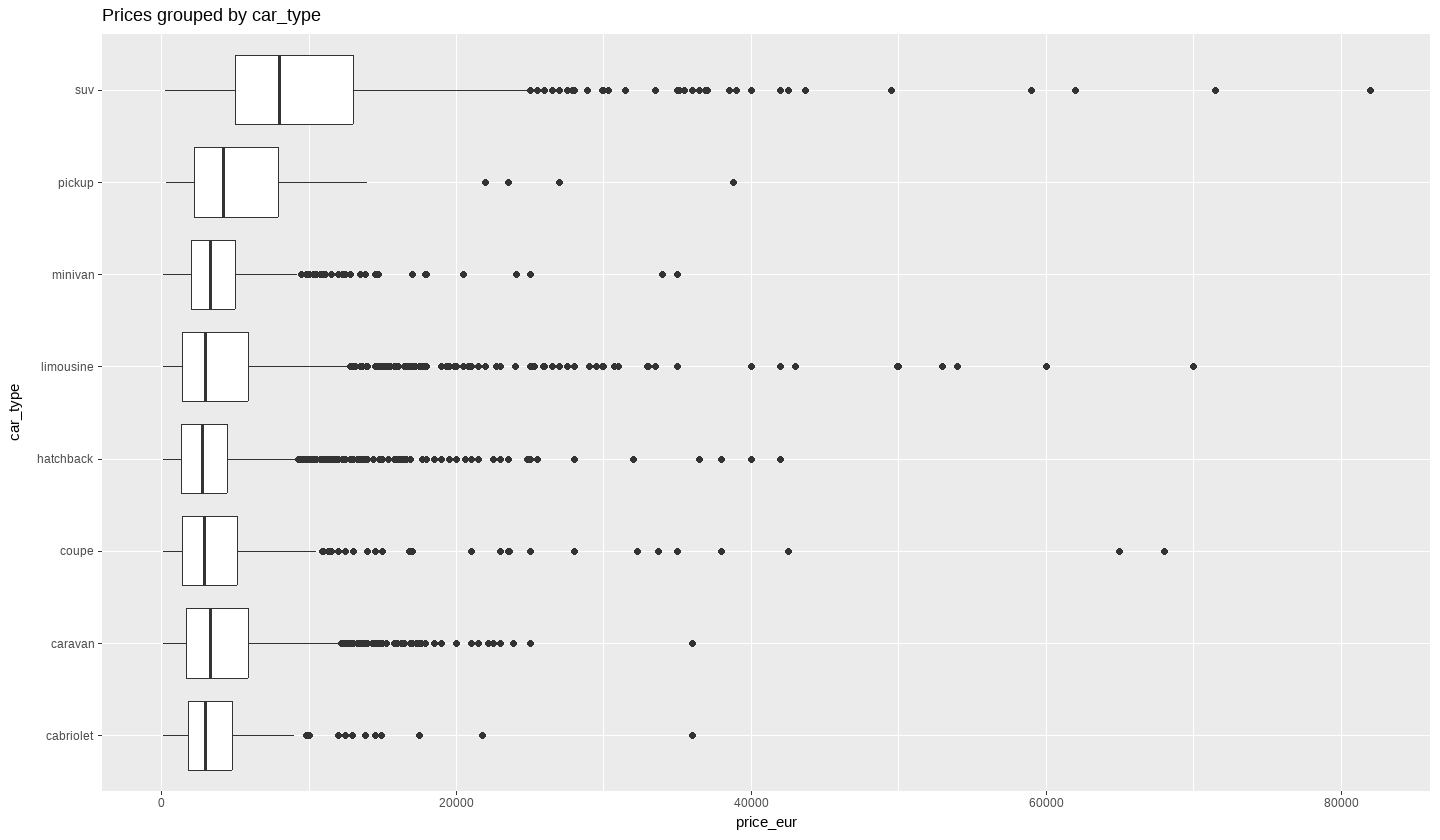

In [54]:
options(repr.plot.width = 12, repr.plot.height = 7)

ggplot(cars, aes(x = car_type, y = price_eur)) +
  geom_boxplot() +
  coord_flip() + 
  labs(title = "Prices grouped by car_type")

corrplot 0.95 loaded



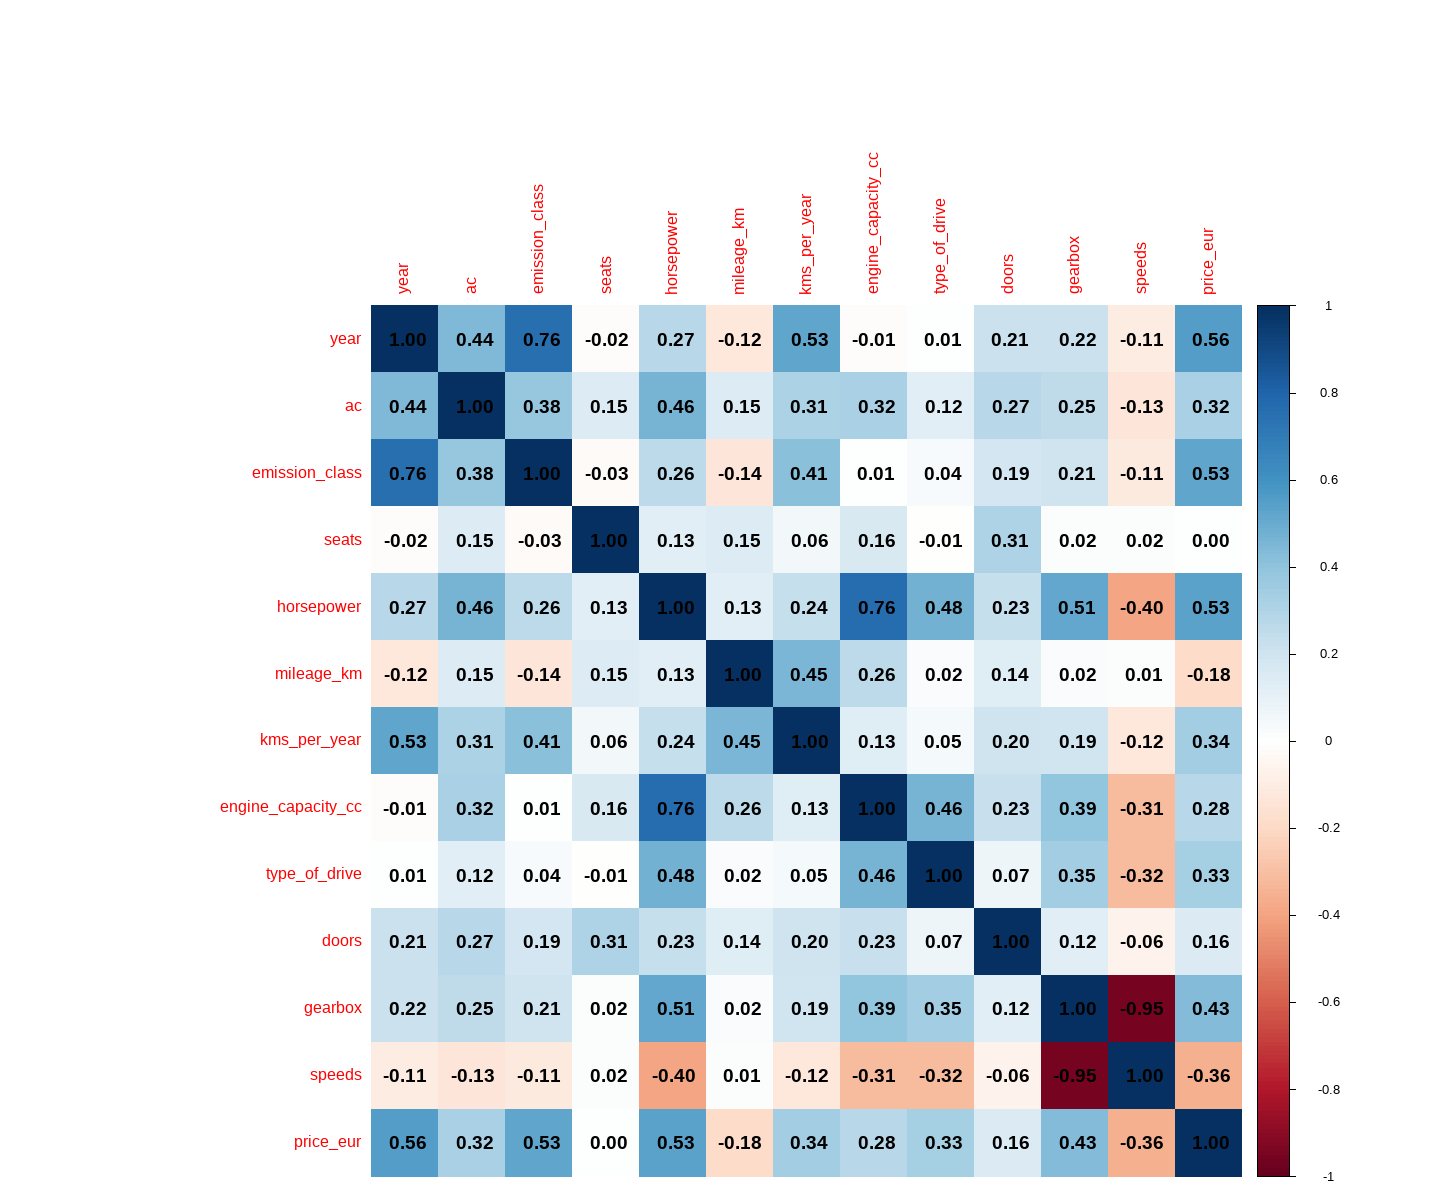

In [55]:
#install.packages("corrplot")
options(repr.plot.width = 12, repr.plot.height = 10)

library(corrplot)
num_vars <- cars %>% select(where(is.numeric)) %>% 
            select(-id, -days_passed, -views, -favorite, -views_per_day, -favs_per_10_views)
M <- cor(num_vars)
corrplot(M, method = "color", addCoef.col = "black", number.cex = 1.2)

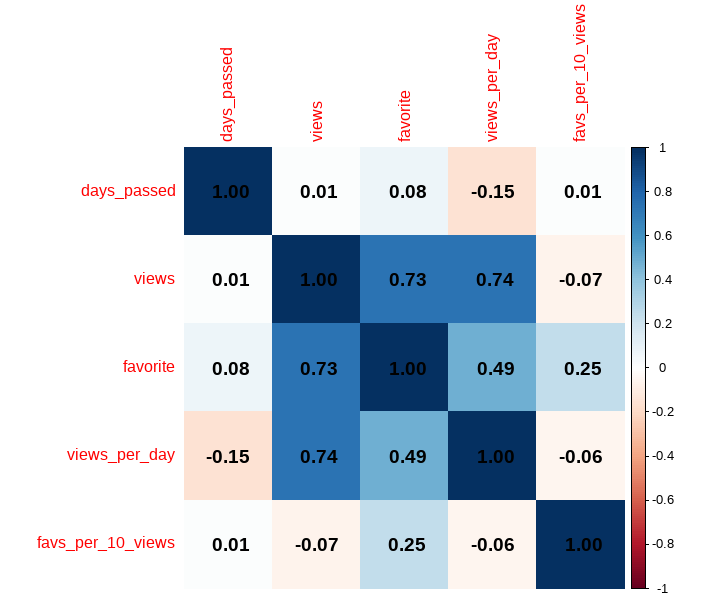

In [56]:
options(repr.plot.width = 6, repr.plot.height = 5)
num_vars <- cars %>%
            select(days_passed, views, favorite, views_per_day, favs_per_10_views)
M <- cor(num_vars)
corrplot(M, method = "color", addCoef.col = "black", number.cex = 1.2)

## Models for predicting price

In [57]:
library(tidymodels)
#install.packages("embed")
library(embed)

── Attaching packages ────────────────────────────────────────────────────────────────────────────── tidymodels 1.4.1 ──

✔ broom        1.0.12     ✔ tailor       0.1.0 
✔ dials        1.4.2      ✔ tune         2.0.1 
✔ infer        1.1.0      ✔ workflows    1.3.0 
✔ modeldata    1.5.1      ✔ workflowsets 1.1.1 
✔ parsnip      1.4.1      ✔ yardstick    1.3.2 
✔ rsample      1.3.2      

── Conflicts ───────────────────────────────────────────────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dlookr::extract() masks tidyr::extract()
✖ dplyr::filter()   masks stats::filter()
✖ recipes::fixed()  masks stringr::fixed()
✖ dplyr::lag()      masks stats::lag()
✖ yardstick::spec() masks readr::spec()
✖ recipes::step()   masks stats::step()



In [58]:
set.seed(123)
car_split <- initial_split(cars, prop = 0.8, strata = price_eur)
train_data <- training(car_split)
test_data  <- testing(car_split)

#### Creating recipe for price prediction

In [59]:
recipe_price <- recipe(price_eur ~ ., data = train_data) %>%
  update_role(id, new_role = "ID") %>%
  update_role(views, favorite, days_passed, views_per_day, favs_per_10_views, new_role = "info") %>%
  step_lencode_mixed(model, outcome = vars(price_eur)) %>%
  step_dummy(brand, color, fuel, car_type) %>%
  step_nzv(all_predictors()) %>%
  step_normalize(all_numeric_predictors(), -has_role("info"), -all_outcomes())

## Random forest

#### Basic random forest model

In [60]:
# Creating the basic model
rf_base_spec <- rand_forest(trees = 500) %>%
  set_engine("ranger", num.threads = 12, importance="impurity") %>%
  set_mode("regression")

# Basic workflow
car_base_wf <- workflow() %>%
  add_recipe(recipe_price) %>%
  add_model(rf_base_spec)

In [61]:
set.seed(456)
base_res <- last_fit(car_base_wf, car_split)

base_predictions <- base_res %>% 
  collect_predictions()

metrics(base_predictions, truth = price_eur, estimate = .pred)

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,2094.0584257
rsq,standard,0.8483042
mae,standard,1054.5037555


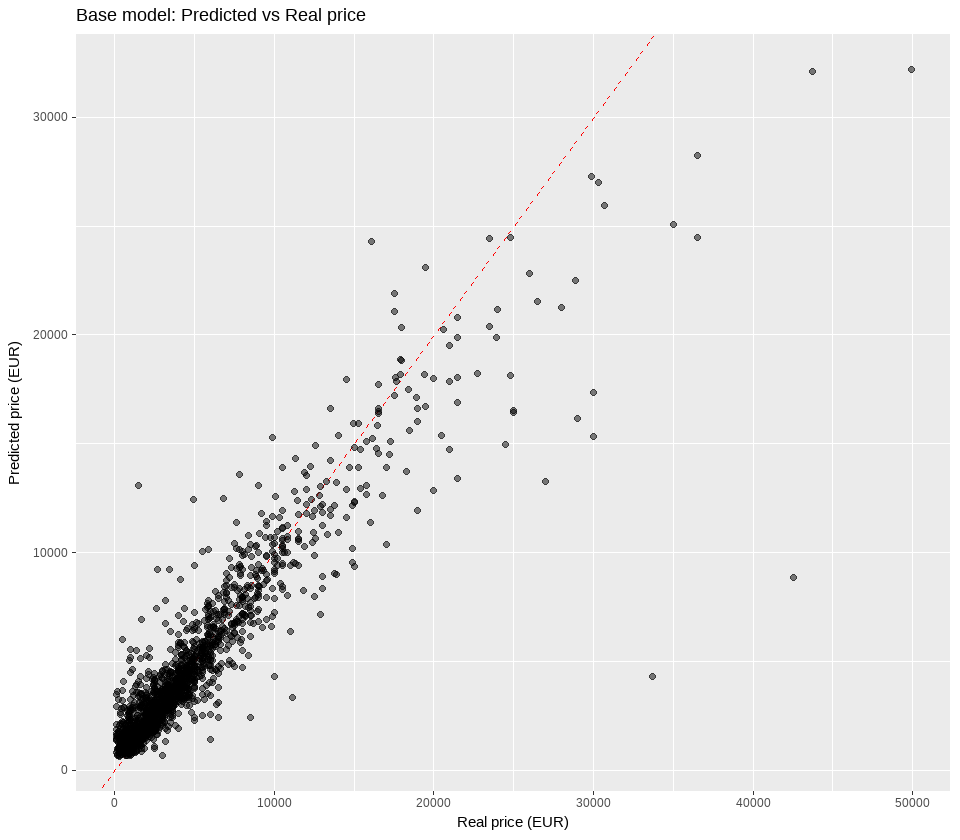

In [62]:
options(repr.plot.width = 8, repr.plot.height = 7)

base_predictions %>%
  ggplot(aes(x = price_eur, y = .pred)) +
  geom_abline(lty = 2, color = "red") +
  geom_point(alpha = 0.5) +
  labs(title = "Base model: Predicted vs Real price",
       x = "Real price (EUR)", y = "Predicted price (EUR)")


Kapcsolódás csomaghoz: 'vip'


The following object is masked from 'package:utils':

    vi




# A tibble: 35 × 2
   Variable             Importance
   <chr>                     <dbl>
 1 year               40983341462.
 2 model              40727272302.
 3 emission_class     22604531349.
 4 horsepower         20468033587.
 5 kms_per_year       11628849963.
 6 mileage_km         11615473620.
 7 engine_capacity_cc  9327510825.
 8 speeds              8119924348.
 9 gearbox             7579713303.
10 type_of_drive       4788450131.
# ℹ 25 more rows


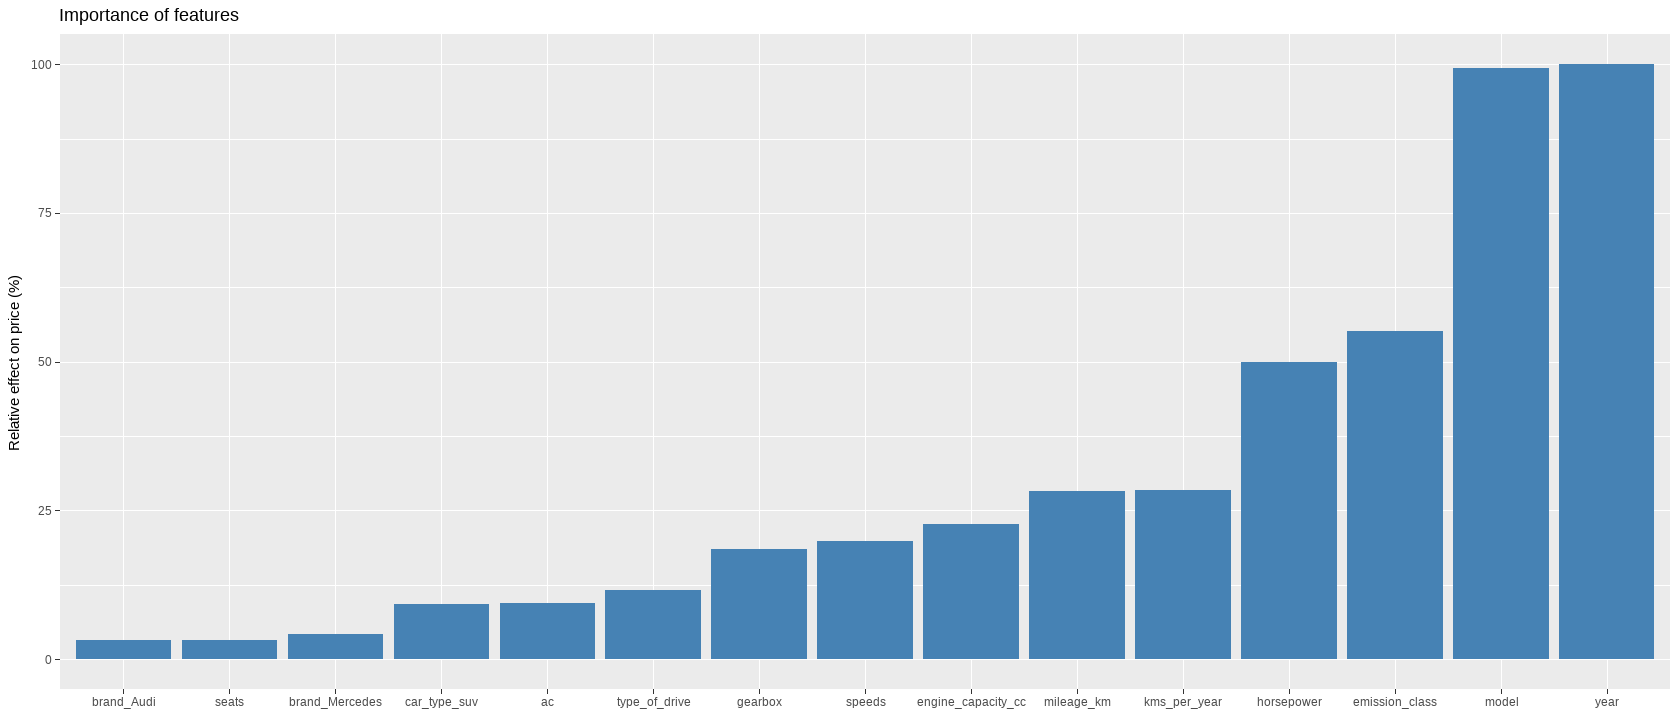

In [63]:
library(vip)

options(repr.plot.width = 14, repr.plot.height = 6)

base_model <- base_res %>% 
  extract_workflow() %>% 
  extract_fit_parsnip()

importance_table <- base_model %>% 
  vi(num_features = 10)

importance_table %>%
  slice_max(Importance, n = 15) %>% 
  mutate(Importance = Importance / max(Importance) * 100) %>%
  ggplot(aes(x = reorder(Variable, Importance), y = Importance)) +
  geom_col(fill = "steelblue") +
  labs(title = "Importance of features", x = NULL, y = "Relative effect on price (%)")

print(importance_table)

#### Hyperparameter tuning

In [64]:
rf_spec <- rand_forest(
    mtry = tune(),
    min_n = tune(),
    trees = 500
  ) %>%
  set_engine("ranger", num.threads = 12) %>%
  set_mode("regression")

car_wf <- workflow() %>%
  add_recipe(recipe_price) %>%
  add_model(rf_spec)

In [65]:
set.seed(456)
car_folds <- vfold_cv(train_data, v = 5, strata = price_eur)

tune_res <- tune_grid(
  car_wf,
  resamples = car_folds,
  grid = 10
)

i Creating pre-processing data to finalize 1 unknown parameter: "mtry"



#### Model with the best RMSE value

In [66]:
best_params_rmse <- select_best(tune_res, metric = "rmse")
final_wf_rmse <- finalize_workflow(car_wf, best_params_rmse)
final_res_rmse <- last_fit(final_wf_rmse, car_split) 

final_predictions_rmse <- final_res_rmse %>%
collect_predictions()

print(best_params_rmse)
metrics(final_predictions_rmse, truth = price_eur, estimate = .pred)

# A tibble: 1 × 3
   mtry min_n .config         
  <int> <int> <chr>           
1     8     2 pre0_mod03_post0


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,2064.5271645
rsq,standard,0.8490152
mae,standard,1028.7465700


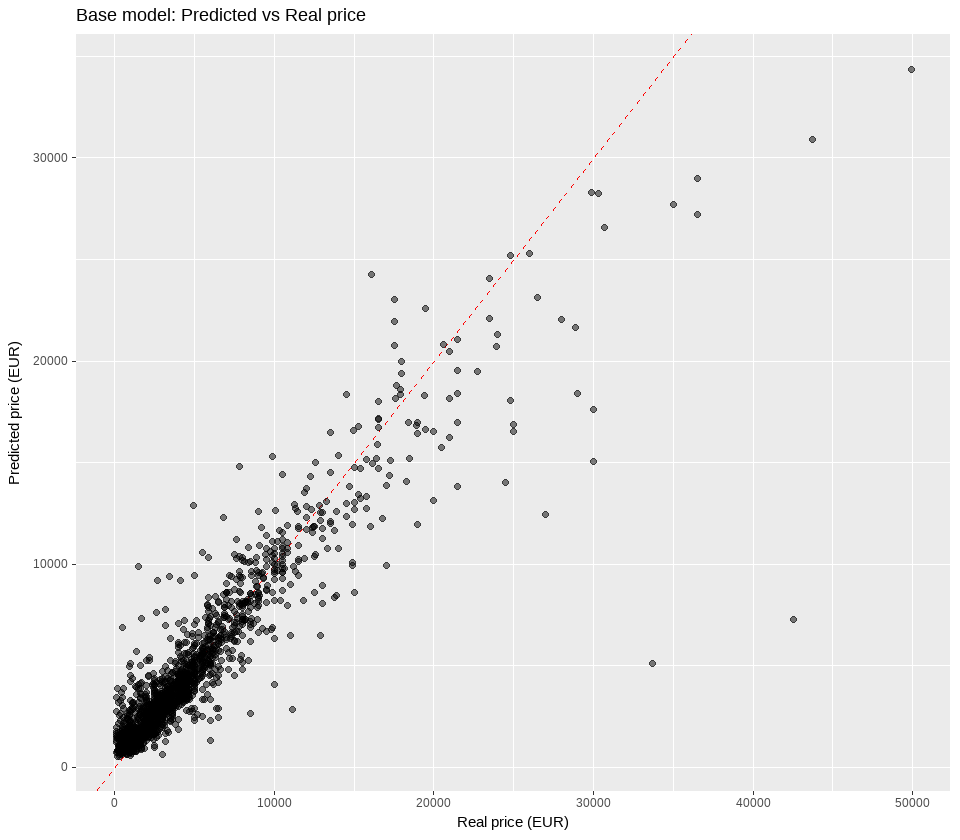

In [67]:
options(repr.plot.width = 8, repr.plot.height = 7)

final_predictions_rmse %>%
  ggplot(aes(x = price_eur, y = .pred)) +
  geom_abline(lty = 2, color = "red") +
  geom_point(alpha = 0.5) +
  labs(title = "Base model: Predicted vs Real price",
       x = "Real price (EUR)", y = "Predicted price (EUR)")

#### Worst and best predictions

In [68]:
predictions <- final_res_rmse %>%
  collect_predictions() %>%
  mutate(error = abs(price_eur - .pred))

best_5 <- predictions %>%
  slice_min(order_by = error, n = 5)

worst_5 <- predictions %>%
  slice_max(order_by = error, n = 5)

print("Best predictions:")
print(best_5)
cars[best_5$.row, ]

print("Worst predictions")
print(worst_5)
cars[worst_5$.row, ]

[1] "Best predictions:"
# A tibble: 5 × 6
  .pred id               price_eur  .row .config         error
  <dbl> <chr>                <int> <int> <chr>           <dbl>
1 1199. train/test split      1199  2809 pre0_mod0_post0 0.148
2  948. train/test split       950  8144 pre0_mod0_post0 1.77 
3 1202. train/test split      1200  1977 pre0_mod0_post0 2.37 
4 4197. train/test split      4200  3653 pre0_mod0_post0 2.95 
5 2646. train/test split      2650  4283 pre0_mod0_post0 4.14 


id,views,favorite,brand,model,days_passed,views_per_day,favs_per_10_views,year,ac,⋯,mileage_km,kms_per_year,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds,price_eur
<int>,<int>,<int>,<fct>,<fct>,<int>,<dbl>,<dbl>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,<int>,<int>,<int>
2849,55,2,Ford,Ka,14,3.67,0.36,2002,1,⋯,100000,4348,1299,0,3,petrol,hatchback,0,5,1199
8259,186,2,Zastava,101,21,8.45,0.11,2008,0,⋯,170000,10000,1116,0,5,petrol,limousine,0,5,950
2010,386,3,Fiat,Bravo,7,48.25,0.08,2001,1,⋯,216355,9015,1600,0,3,petrol,hatchback,0,5,1200
3706,72,1,Mercedes,C 200,7,9.00,0.14,2006,2,⋯,279000,14684,2148,1,5,diesel,caravan,0,6,4200
4349,161,2,Opel,Astra H,21,7.32,0.12,2006,1,⋯,187628,9875,1686,0,3,diesel,hatchback,0,5,2650


[1] "Worst predictions"
# A tibble: 5 × 6
   .pred id               price_eur  .row .config          error
   <dbl> <chr>                <int> <int> <chr>            <dbl>
1  7270. train/test split     42500  5478 pre0_mod0_post0 35230.
2  5098. train/test split     33699  3504 pre0_mod0_post0 28601.
3 34367. train/test split     49900   569 pre0_mod0_post0 15533.
4 15049. train/test split     29999  1260 pre0_mod0_post0 14950.
5 12466. train/test split     27000  1277 pre0_mod0_post0 14534.


id,views,favorite,brand,model,days_passed,views_per_day,favs_per_10_views,year,ac,⋯,mileage_km,kms_per_year,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds,price_eur
<int>,<int>,<int>,<fct>,<fct>,<int>,<dbl>,<dbl>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,<int>,<int>,<int>
5560,2434,18,Porsche,911,3,608.50,0.07,2004,2,⋯,117000,5571,3596,1,3,petrol,coupe,2,0,42500
3556,796,4,Mercedes,280,4,159.20,0.05,1979,0,⋯,370000,8043,3000,1,3,diesel,coupe,0,5,33699
580,1501,5,Audi,A6,21,68.23,0.03,2020,2,⋯,47000,9400,1968,2,5,diesel,limousine,2,0,49900
1281,148,0,BMW,X5,21,6.73,0.00,2015,2,⋯,211000,21100,2000,2,5,diesel,suv,2,0,29999
1298,1906,11,BMW,X5 M,3,476.50,0.06,2012,2,⋯,204000,15692,2996,2,5,diesel,suv,2,0,27000
